# Modélisation et évaluation

Ce notebook construit un pipeline complet de machine learning afin de prédire la
survie des passagers du Titanic.

Le pipeline regroupe :

1. le feature engineering ;
2. l'imputation des valeurs manquantes ;
3. la standardisation des variables numériques ;
4. l'encodage des variables catégorielles ;
5. le modèle de classification.

Plusieurs algorithmes seront comparés avec une validation croisée stratifiée. Le
meilleur candidat sera ensuite optimisé et évalué une seule fois sur un jeu de
validation conservé à l'écart.

Enfin, le modèle sera réentraîné sur l'ensemble du jeu d'entraînement et utilisé pour
générer une soumission Kaggle.

---

## Importations et configuration

In [1]:
from pathlib import Path
import sys
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OneHotEncoder,
    StandardScaler
)
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(
    style="whitegrid",
    context="notebook"
)

RANDOM_STATE = 42

---

## Détection robuste de la racine du projet

In [2]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    raise FileNotFoundError(
        "Impossible de localiser la racine du projet."
    )

DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
SUBMISSIONS_DIR = PROJECT_ROOT / "submissions"

for directory in [
    MODELS_DIR,
    REPORTS_DIR,
    FIGURES_DIR,
    SUBMISSIONS_DIR
]:
    directory.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"Racine du projet : {PROJECT_ROOT}")

Racine du projet : c:\Users\hoare\Programming\project\titanic-project


---

## Importation du feature engineering

In [3]:
from src.features import (
    build_model_features,
    MODEL_FEATURES,
    NUMERIC_FEATURES,
    CATEGORICAL_FEATURES
)

On va venir vérifier les listes de variables

In [4]:
print("Variables finales :")
print(MODEL_FEATURES)

print("\nVariables numériques :")
print(NUMERIC_FEATURES)

print("\nVariables catégorielles :")
print(CATEGORICAL_FEATURES)

Variables finales :
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FamilyGroup', 'Title', 'CabinKnown', 'Deck', 'TicketPrefix', 'NameLength']

Variables numériques :
['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'NameLength']

Variables catégorielles :
['Pclass', 'Sex', 'Embarked', 'IsAlone', 'FamilyGroup', 'Title', 'CabinKnown', 'Deck', 'TicketPrefix']


---

## Chargement des données

Les modèles seront entraînés à partir des données brutes. Toutes les transformations
seront réalisées par le pipeline afin que la même logique soit appliquée aux données
d'entraînement, de validation et de test.

In [5]:
train_path = DATA_DIR / "train.csv"
test_path = DATA_DIR / "test.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Train : {train_df.shape}")
print(f"Test  : {test_df.shape}")

Train : (891, 12)
Test  : (418, 11)


### Vérifications

In [6]:
TARGET = "Survived"
ID_COLUMN = "PassengerId"

assert TARGET in train_df.columns, (
    "La cible Survived est absente du jeu d'entraînement."
)

assert TARGET not in test_df.columns, (
    "La cible ne doit pas être présente dans le jeu de test."
)

assert train_df[ID_COLUMN].is_unique
assert test_df[ID_COLUMN].is_unique

common_ids = set(train_df[ID_COLUMN]).intersection(
    set(test_df[ID_COLUMN])
)

assert len(common_ids) == 0

print("Structure des données validée.")

Structure des données validée.


---

## Séparation de la cible et conservation des identifiants

In [7]:
X = train_df.drop(columns=TARGET).copy()
y = train_df[TARGET].copy()

X_test = test_df.copy()
test_passenger_ids = test_df[ID_COLUMN].copy()

print(f"X      : {X.shape}")
print(f"y      : {y.shape}")
print(f"X_test : {X_test.shape}")

X      : (891, 11)
y      : (891,)
X_test : (418, 11)


In [8]:
target_distribution = (
    y.value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_distribution

Survived
0    61.62
1    38.38
Name: proportion, dtype: float64

La classe majoritaire correspond aux non-survivants. Un modèle prédisant
systématiquement cette classe obtiendrait environ 50 % d'accuracy. Les modèles
entraînés devront donc être comparés à cette baseline minimale.

---

## Séparation développement-validation

Un jeu de validation final est conservé à l'écart avant la comparaison des modèles.
La stratification permet de maintenir une proportion similaire de survivants et de
non-survivants dans les deux sous-ensembles.

Le jeu de validation ne sera pas utilisé pour sélectionner les modèles ni pour
optimiser leurs hyperparamètres.

In [9]:
X_development, X_validation, y_development, y_validation = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        stratify=y,
        random_state=RANDOM_STATE
    )
)

print(f"Développement : {X_development.shape}")
print(f"Validation    : {X_validation.shape}")

Développement : (712, 11)
Validation    : (179, 11)


### Vérification de la stratisfication

In [10]:
split_distribution = pd.DataFrame({
    "Ensemble complet": y.value_counts(normalize=True),
    "Développement": y_development.value_counts(normalize=True),
    "Validation": y_validation.value_counts(normalize=True)
}).sort_index()

split_distribution = (
    split_distribution
    .mul(100)
    .round(2)
)

split_distribution

,Ensemble complet,Développement,Validation
Survived,,,
0,61.62,61.66,61.45
1,38.38,38.34,38.55


---

## Pipeline de preprocessing

La première étape du pipeline applique la fonction de feature engineering aux données
brutes. La fonction ne dépend pas de la cible et n'apprend aucun paramètre statistique.

L'imputation, la standardisation et l'encodage sont ensuite ajustés uniquement sur les
observations utilisées pour l'entraînement.


In [11]:
feature_engineering = FunctionTransformer(
    build_model_features,
    validate=False
)

In [12]:
X_development_engineered = feature_engineering.fit_transform(
    X_development
)

print(X_development_engineered.shape)
X_development_engineered.head()

(712, 15)


,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,FamilyGroup,Title,CabinKnown,Deck,TicketPrefix,NameLength
692,3,male,NaN,0,0,56.4958,S,1,1,Alone,Mr,0,U,NONE,12
481,2,male,NaN,0,0,0.0000,S,1,1,Alone,Mr,0,U,NONE,32
527,1,male,NaN,0,0,221.7792,S,1,1,Alone,Mr,1,C,PC,18
855,3,female,18.0,0,1,9.3500,S,2,0,Small,Mrs,0,U,NONE,26
801,2,female,31.0,1,1,26.2500,S,3,0,Small,Mrs,0,U,CA,43


In [13]:
assert list(X_development_engineered.columns) == MODEL_FEATURES
assert TARGET not in X_development_engineered.columns

print("Feature engineering validé.")

Feature engineering validé.


---

## Pipeline numérique
Les variables numériques recevront :
- une imputation par la médiane
- une standardisation

In [14]:
numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

La **standardisation** est particulièrement utile pour la *régression logistique*. Elle n'est pas forcément nécessaire pour les abres, mais elle ne les empêche pas de fonctionner.

---

## Pipeline catégoriel

Les variables catégorielles recevront :
- une imputation par la modalité la plus fréquente
- un one-hot enconding

In [15]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                min_frequency=2,
                sparse_output=False
            )
        )
    ]
)

Ici `handle_unknown="ignore"` empêche une erreur si une catégorie apparaît dans le jeu de test sans avoir été observée pendant l'entraînement.

`min_frequency=2` permet de regrouper automatiquement les modalités n'apparaissant qu'une seule fois.

---

## ColumnTransformer

In [16]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_pipeline,
            NUMERIC_FEATURES
        ),
        (
            "categorical",
            categorical_pipeline,
            CATEGORICAL_FEATURES
        )
    ],
    remainder="drop",
    verbose_feature_names_out=False
)

---

## Fonction de création du pipeline complet

In [17]:
def make_model_pipeline(model):
    """
    Construit un pipeline complet contenant le feature engineering,
    le preprocessing et le modèle.
    """
    return Pipeline(
        steps=[
            (
                "feature_engineering",
                feature_engineering
            ),
            (
                "preprocessing",
                preprocessor
            ),
            (
                "model",
                model
            )
        ]
    )

---

## Définition des modèles candidats
Pour cela je vais comparer :
- une baseline naïve
- une régression logistique
- un arbre de décision
- une forêt aléatoire
- un gradient boosting

In [18]:
models = {
    "DummyClassifier": DummyClassifier(
        strategy="most_frequent"
    ),

    "LogisticRegression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),

    "DecisionTree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestClassifier(
        n_estimators=400,
        random_state=RANDOM_STATE,
        n_jobs=1
    ),

    "GradientBoosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    )
}

In [19]:
model_pipelines = {
    name: make_model_pipeline(model)
    for name, model in models.items()
}

---

## Comparaison par validation croisée

Les modèles sont comparés avec une validation croisée stratifiée à cinq plis.

À chaque pli :

- le feature engineering est appliqué ;
- l'imputation est ajustée sur les données d'entraînement du pli ;
- la standardisation et l'encodage sont ajustés sur ces mêmes données ;
- le modèle est entraîné ;
- les performances sont mesurées sur le pli de validation.

Cette organisation évite les fuites de données.


In [20]:
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

In [21]:
scoring = {
    "accuracy": "accuracy",

    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),

    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),

    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),

    "roc_auc": "roc_auc"
}

L'accuracy restera la métrique principale, car elle correspond à la métrique utilisée par la compétition *Kaggle*. Les autres métriques permettront de mieux comprendre les comportements des modèles.

---

## Comparaison des modèles

In [22]:
comparison_rows = []

for model_name, pipeline in model_pipelines.items():
    print(f"Évaluation de {model_name}...")

    cv_results = cross_validate(
        estimator=pipeline,
        X=X_development,
        y=y_development,
        cv=cross_validation,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )

    comparison_rows.append({
        "model": model_name,
        "accuracy_mean": cv_results[
            "test_accuracy"
        ].mean(),
        "accuracy_std": cv_results[
            "test_accuracy"
        ].std(),
        "precision_mean": cv_results[
            "test_precision"
        ].mean(),
        "recall_mean": cv_results[
            "test_recall"
        ].mean(),
        "f1_mean": cv_results[
            "test_f1"
        ].mean(),
        "roc_auc_mean": cv_results[
            "test_roc_auc"
        ].mean(),
        "fit_time_mean": cv_results[
            "fit_time"
        ].mean()
    })

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values(
        "accuracy_mean",
        ascending=False
    )
    .reset_index(drop=True)
)

comparison_df

Évaluation de DummyClassifier...
Évaluation de LogisticRegression...
Évaluation de DecisionTree...
Évaluation de RandomForest...
Évaluation de GradientBoosting...


,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_mean
0,LogisticRegression,0.825874,0.028416,0.785355,0.754613,0.769151,0.873354,0.078098
1,RandomForest,0.824446,0.018185,0.795100,0.736364,0.762753,0.882686,0.603714
2,GradientBoosting,0.816005,0.027866,0.793833,0.706869,0.746364,0.885708,0.169701
3,DecisionTree,0.782350,0.025852,0.733905,0.681684,0.705043,0.762648,0.040626
4,DummyClassifier,0.616576,0.002749,0.000000,0.000000,0.000000,0.500000,0.068641


### Formattage des résultats

In [23]:
formatted_comparison = comparison_df.copy()

metric_columns = [
    "accuracy_mean",
    "accuracy_std",
    "precision_mean",
    "recall_mean",
    "f1_mean",
    "roc_auc_mean"
]

formatted_comparison[metric_columns] = (
    formatted_comparison[metric_columns]
    .round(4)
)

formatted_comparison["fit_time_mean"] = (
    formatted_comparison["fit_time_mean"]
    .round(3)
)

formatted_comparison

,model,accuracy_mean,accuracy_std,precision_mean,recall_mean,f1_mean,roc_auc_mean,fit_time_mean
0,LogisticRegression,0.8259,0.0284,0.7854,0.7546,0.7692,0.8734,0.078
1,RandomForest,0.8244,0.0182,0.7951,0.7364,0.7628,0.8827,0.604
2,GradientBoosting,0.8160,0.0279,0.7938,0.7069,0.7464,0.8857,0.170
3,DecisionTree,0.7824,0.0259,0.7339,0.6817,0.7050,0.7626,0.041
4,DummyClassifier,0.6166,0.0027,0.0000,0.0000,0.0000,0.5000,0.069


## Sauvegarde des résultats

In [24]:
comparison_path = (
    REPORTS_DIR
    / "model_comparison.csv"
)

comparison_df.to_csv(
    comparison_path,
    index=False
)

print(f"Résultats sauvegardés dans : {comparison_path}")

Résultats sauvegardés dans : c:\Users\hoare\Programming\project\titanic-project\reports\model_comparison.csv


---

## visualisation de la comparaison

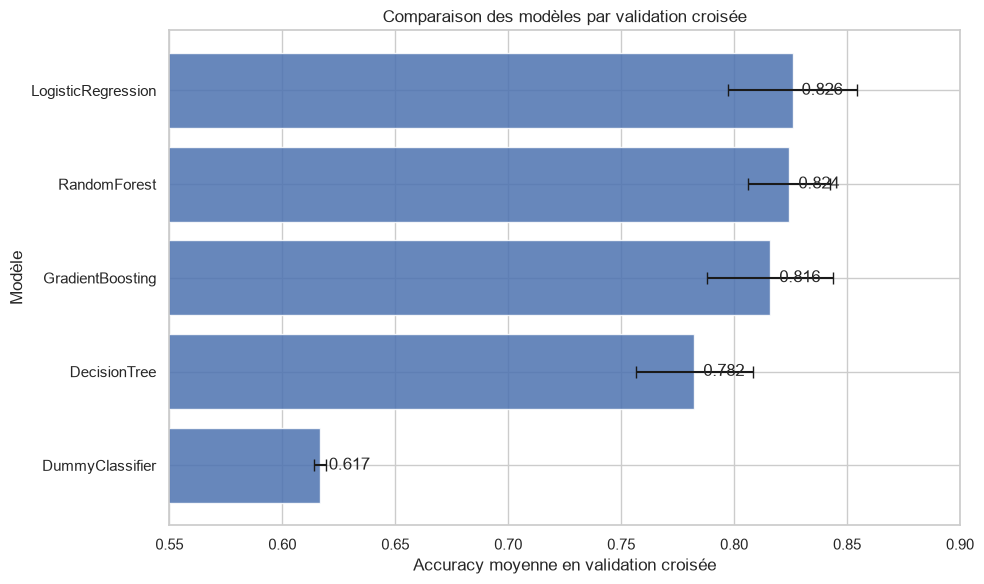

In [25]:
plot_df = comparison_df.sort_values(
    "accuracy_mean",
    ascending=True
)

plt.figure(figsize=(10, 6))

ax = plt.barh(
    y=plot_df["model"],
    width=plot_df["accuracy_mean"],
    xerr=plot_df["accuracy_std"],
    color="#4C72B0",
    alpha=0.85,
    capsize=4
)

plt.xlabel("Accuracy moyenne en validation croisée")
plt.ylabel("Modèle")
plt.title("Comparaison des modèles par validation croisée")
plt.xlim(0.55, 0.90)

for bar, score in zip(
    ax,
    plot_df["accuracy_mean"]
):
    plt.text(
        score + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{score:.3f}",
        va="center"
    )

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Comparaison avec toute les métriques

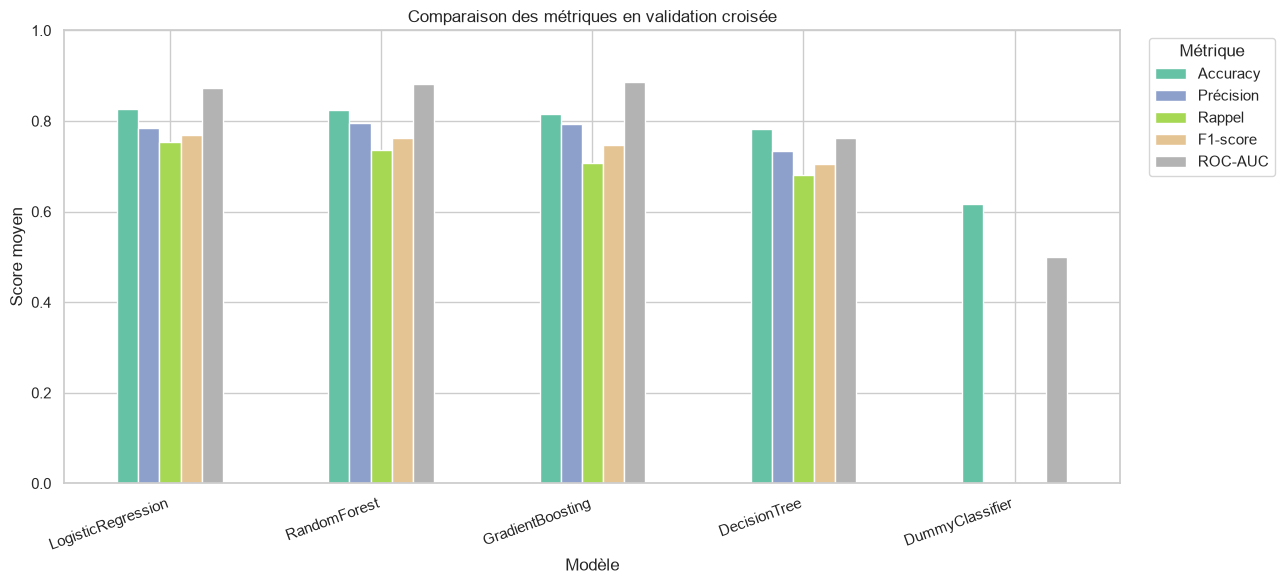

In [27]:
metrics_plot_df = (
    comparison_df
    .set_index("model")[
        [
            "accuracy_mean",
            "precision_mean",
            "recall_mean",
            "f1_mean",
            "roc_auc_mean",
        ]
    ]
    .rename(
        columns={
            "accuracy_mean": "Accuracy",
            "precision_mean": "Précision",
            "recall_mean": "Rappel",
            "f1_mean": "F1-score",
            "roc_auc_mean": "ROC-AUC",
        }
    )
)

ax = metrics_plot_df.plot(
    kind="bar",
    figsize=(13, 6),
    ylim=(0, 1),
    colormap="Set2",
)

ax.set_title("Comparaison des métriques en validation croisée")
ax.set_xlabel("Modèle")
ax.set_ylabel("Score moyen")

plt.xticks(rotation=20, ha="right")

plt.legend(
    title="Métrique",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "model_comparison_metrics.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

---

## Identification du meilleur modèle non naïf

In [28]:
candidate_results = comparison_df[
    comparison_df["model"] != "DummyClassifier"
].copy()

selected_model_name = candidate_results.iloc[0]["model"]

print(
    "Meilleur modèle avant optimisation :",
    selected_model_name
)

Meilleur modèle avant optimisation : LogisticRegression


on va venir récupérer le pipeline

In [29]:
selected_pipeline = model_pipelines[
    selected_model_name
]

---

## Définition des espaces d'hyperparamètres

In [30]:
search_spaces = {
    "LogisticRegression": {
        "model__C": [
            0.01,
            0.03,
            0.1,
            0.3,
            1.0,
            3.0,
            10.0
        ],
        "model__class_weight": [
            None,
            "balanced"
        ]
    },

    "DecisionTree": {
        "model__criterion": [
            "gini",
            "entropy"
        ],
        "model__max_depth": [
            3,
            4,
            5,
            6,
            8,
            None
        ],
        "model__min_samples_split": [
            2,
            5,
            10,
            20
        ],
        "model__min_samples_leaf": [
            1,
            2,
            5,
            10
        ],
        "model__class_weight": [
            None,
            "balanced"
        ]
    },

    "RandomForest": {
        "model__n_estimators": [
            300,
            500,
            700
        ],
        "model__max_depth": [
            None,
            5,
            8,
            12
        ],
        "model__min_samples_split": [
            2,
            5,
            10
        ],
        "model__min_samples_leaf": [
            1,
            2,
            4
        ],
        "model__max_features": [
            "sqrt",
            0.5
        ],
        "model__class_weight": [
            None,
            "balanced"
        ]
    },

    "GradientBoosting": {
        "model__n_estimators": [
            50,
            100,
            150,
            250
        ],
        "model__learning_rate": [
            0.01,
            0.03,
            0.05,
            0.1
        ],
        "model__max_depth": [
            1,
            2,
            3,
            4
        ],
        "model__min_samples_leaf": [
            1,
            3,
            5,
            10
        ],
        "model__subsample": [
            0.7,
            0.85,
            1.0
        ]
    }
}

---

## Optimisation du meilleur candidat
On utilisera :
- `GridSearchCV` si l'espace de recherche est petit
- `RandomizedSearchCV` s'il est plus grand

In [31]:
selected_search_space = search_spaces[
    selected_model_name
]

number_of_combinations = len(
    list(ParameterGrid(selected_search_space))
)

print(
    "Nombre total de combinaisons :",
    number_of_combinations
)

Nombre total de combinaisons : 14


### Lancement de la recherche

In [32]:
if number_of_combinations <= 40:
    search = GridSearchCV(
        estimator=selected_pipeline,
        param_grid=selected_search_space,
        scoring=scoring,
        refit="accuracy",
        cv=cross_validation,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )
else:
    search = RandomizedSearchCV(
        estimator=selected_pipeline,
        param_distributions=selected_search_space,
        n_iter=min(40, number_of_combinations),
        scoring=scoring,
        refit="accuracy",
        cv=cross_validation,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        return_train_score=True,
        verbose=1
    )

In [33]:
search.fit(
    X_development,
    y_development
)

Fitting 5 folds for each of 14 candidates, totalling 70 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.03, ...], 'model__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","{'accuracy': 'accuracy', 'f1': make_scorer(f...ro_division=0), 'precision': make_scorer(p...ro_division=0), 'recall': make_scorer(r...ro_division=0), ...}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'accuracy'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can 

### Meilleurs résultats

In [39]:
print(
    "Meilleure accuracy moyenne :",
    round(search.best_score_, 4)
)

print("\nMeilleurs hyperparamètres :")

for parameter, value in search.best_params_.items():
    print(f"- {parameter}: {value}")

Meilleure accuracy moyenne : 0.8287

Meilleurs hyperparamètres :
- model__C: 3.0
- model__class_weight: None


In [40]:
best_pipeline = search.best_estimator_

---

## Analyse des résultats de l'optimisation

In [35]:
search_results = pd.DataFrame(
    search.cv_results_
)

search_results = (
    search_results
    .sort_values(
        "rank_test_accuracy"
    )
    .reset_index(drop=True)
)

search_results[
    [
        "rank_test_accuracy",
        "mean_train_accuracy",
        "mean_test_accuracy",
        "std_test_accuracy",
        "mean_test_f1",
        "mean_test_roc_auc",
        "params"
    ]    
].head(10)

,rank_test_accuracy,mean_train_accuracy,mean_test_accuracy,std_test_accuracy,mean_test_f1,mean_test_roc_auc,params
0,1,0.851126,0.828671,0.026045,0.772889,0.873820,"{'model__C': 3.0, 'model__class_weight': None}"
1,2,0.846212,0.825874,0.028416,0.769151,0.873354,"{'model__C': 1.0, 'model__class_weight': None}"
2,3,0.855339,0.824476,0.028243,0.767684,0.873056,"{'model__C': 10.0, 'model__class_weight': None}"
3,4,0.834971,0.824456,0.024232,0.764058,0.866883,"{'model__C': 0.1, 'model__class_weight': None}"
4,5,0.841645,0.823067,0.029787,0.776123,0.873935,"{'model__C': 1.0, 'model__class_weight': 'bala..."
5,6,0.840240,0.821668,0.030146,0.773010,0.872526,"{'model__C': 3.0, 'model__class_weight': 'bala..."
6,7,0.839888,0.821649,0.022790,0.761903,0.871680,"{'model__C': 0.3, 'model__class_weight': None}"
7,8,0.837082,0.821639,0.035180,0.774211,0.870647,"{'model__C': 0.3, 'model__class_weight': 'bala..."
8,9,0.842347,0.820260,0.029813,0.771081,0.870964,"{'model__C': 10.0, 'model__class_weight': 'bal..."
9,10,0.823382,0.818802,0.029400,0.749718,0.863782,"{'model__C': 0.03, 'model__class_weight': None}"


### Écart entraînement-validation

In [36]:
search_results["generalization_gap"] = (
    search_results["mean_train_accuracy"]
    - search_results["mean_test_accuracy"]
)

search_results[
    [
        "rank_test_accuracy",
        "mean_train_accuracy",
        "mean_test_accuracy",
        "generalization_gap",
        "params"
    ]
].head(10)


,rank_test_accuracy,mean_train_accuracy,mean_test_accuracy,generalization_gap,params
0,1,0.851126,0.828671,0.022454,"{'model__C': 3.0, 'model__class_weight': None}"
1,2,0.846212,0.825874,0.020337,"{'model__C': 1.0, 'model__class_weight': None}"
2,3,0.855339,0.824476,0.030864,"{'model__C': 10.0, 'model__class_weight': None}"
3,4,0.834971,0.824456,0.010515,"{'model__C': 0.1, 'model__class_weight': None}"
4,5,0.841645,0.823067,0.018578,"{'model__C': 1.0, 'model__class_weight': 'bala..."
5,6,0.840240,0.821668,0.018572,"{'model__C': 3.0, 'model__class_weight': 'bala..."
6,7,0.839888,0.821649,0.018240,"{'model__C': 0.3, 'model__class_weight': None}"
7,8,0.837082,0.821639,0.015443,"{'model__C': 0.3, 'model__class_weight': 'bala..."
8,9,0.842347,0.820260,0.022087,"{'model__C': 10.0, 'model__class_weight': 'bal..."
9,10,0.823382,0.818802,0.004580,"{'model__C': 0.03, 'model__class_weight': None}"


Il faut prendre en compte q'un écart très important entre les performances d'entraînement et validation croisée peut indiquer du surapprentissage.

### Sauvegarde

In [37]:
search_results.to_csv(
    REPORTS_DIR / "hyperparameter_search_results.csv",
    index=False
)

---

## Évaluation finale

Le pipeline optimisé est évalué une seule fois sur le jeu de validation conservé à
l'écart.

Cette évaluation constitue notre meilleure estimation interne des performances du
modèle avant son réentraînement sur l'ensemble des données.


### Prédictions

In [41]:
validation_predictions = best_pipeline.predict(
    X_validation
)

validation_probabilities = best_pipeline.predict_proba(
    X_validation
)[:, 1]

### Métriques

In [42]:
validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        validation_predictions
    ),
    "precision": precision_score(
        y_validation,
        validation_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_validation,
        validation_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_validation,
        validation_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        validation_probabilities
    )
}

validation_metrics_df = pd.DataFrame(
    validation_metrics,
    index=["Optimized model"]
).T

validation_metrics_df

,Optimized model
accuracy,0.821229
precision,0.768116
recall,0.768116
f1_score,0.768116
roc_auc,0.873913


### Baseline sur le même jeu de validation

In [43]:
dummy_pipeline = model_pipelines[
    "DummyClassifier"
]

dummy_pipeline.fit(
    X_development,
    y_development
)

dummy_predictions = dummy_pipeline.predict(
    X_validation
)

dummy_probabilities = dummy_pipeline.predict_proba(
    X_validation
)[:, 1]

dummy_validation_metrics = {
    "accuracy": accuracy_score(
        y_validation,
        dummy_predictions
    ),
    "precision": precision_score(
        y_validation,
        dummy_predictions,
        zero_division=0
    ),
    "recall": recall_score(
        y_validation,
        dummy_predictions,
        zero_division=0
    ),
    "f1_score": f1_score(
        y_validation,
        dummy_predictions,
        zero_division=0
    ),
    "roc_auc": roc_auc_score(
        y_validation,
        dummy_probabilities
    )
}

### Comparaison

In [44]:
final_comparison = pd.DataFrame({
    "DummyClassifier": dummy_validation_metrics,
    "OptimizedModel": validation_metrics
}).T

final_comparison.round(4)

,accuracy,precision,recall,f1_score,roc_auc
DummyClassifier,0.6145,0.0000,0.0000,0.0000,0.5000
OptimizedModel,0.8212,0.7681,0.7681,0.7681,0.8739


---

## Rapport de la classification

In [45]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=[
            "Non survivant",
            "Survivant"
        ],
        output_dict=True,
        zero_division=0
    )
).T

classification_report_df.round(3)

,precision,recall,f1-score,support
Non survivant,0.855,0.855,0.855,110.000
Survivant,0.768,0.768,0.768,69.000
accuracy,0.821,0.821,0.821,0.821
macro avg,0.811,0.811,0.811,179.000
weighted avg,0.821,0.821,0.821,179.000


Le modèle optimisé dépasse nettement la baseline naïve. L'accuracy indique la
proportion totale de prédictions correctes, tandis que la précision et le rappel
décrivent plus précisément le comportement du modèle sur la classe des survivants.

Le rappel des survivants représente la proportion de survivants correctement
identifiés. La précision représente la proportion de survivants réels parmi les
passagers prédits comme survivants.

---

## Matrice de confusion

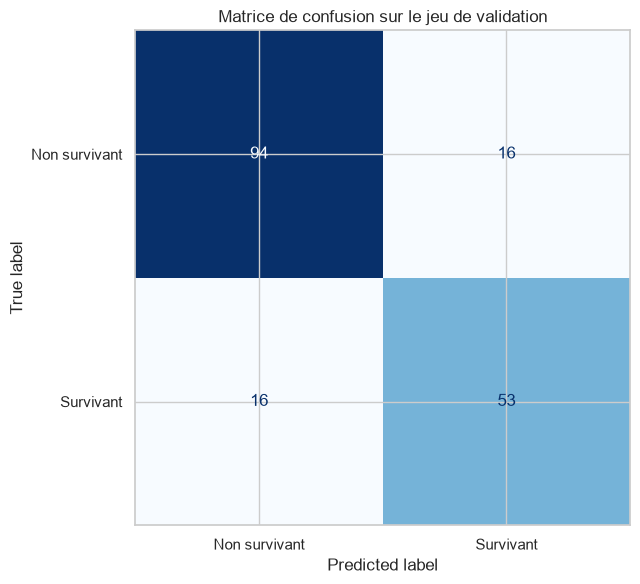

In [46]:
confusion = confusion_matrix(
    y_validation,
    validation_predictions
)

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=[
        "Non survivant",
        "Survivant"
    ]
)

fig, ax = plt.subplots(figsize=(7, 6))

display_matrix.plot(
    cmap="Blues",
    values_format="d",
    ax=ax,
    colorbar=False
)

ax.set_title(
    "Matrice de confusion sur le jeu de validation"
)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "validation_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Ici les cases correspondent à :
```text
            Prédit non survivant   Prédit survivant

Réel non         Vrai négatif         Faux positif
Réel survivant   Faux négatif         Vrai positif
```

---

## Courbe ROC

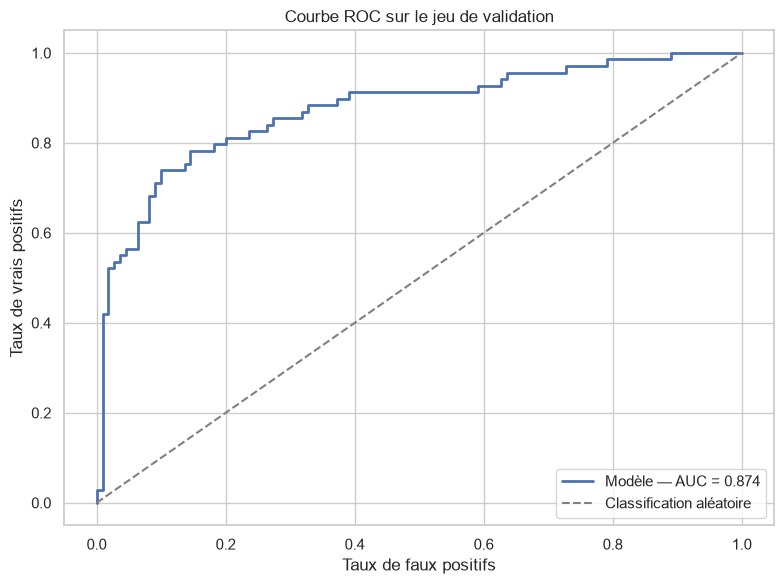

In [47]:
false_positive_rate, true_positive_rate, _ = roc_curve(
    y_validation,
    validation_probabilities
)

validation_auc = roc_auc_score(
    y_validation,
    validation_probabilities
)

plt.figure(figsize=(8, 6))

plt.plot(
    false_positive_rate,
    true_positive_rate,
    color="#4C72B0",
    linewidth=2,
    label=f"Modèle — AUC = {validation_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="Classification aléatoire"
)

plt.xlabel("Taux de faux positifs")
plt.ylabel("Taux de vrais positifs")
plt.title("Courbe ROC sur le jeu de validation")
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "validation_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

## Courbe précision-rappel

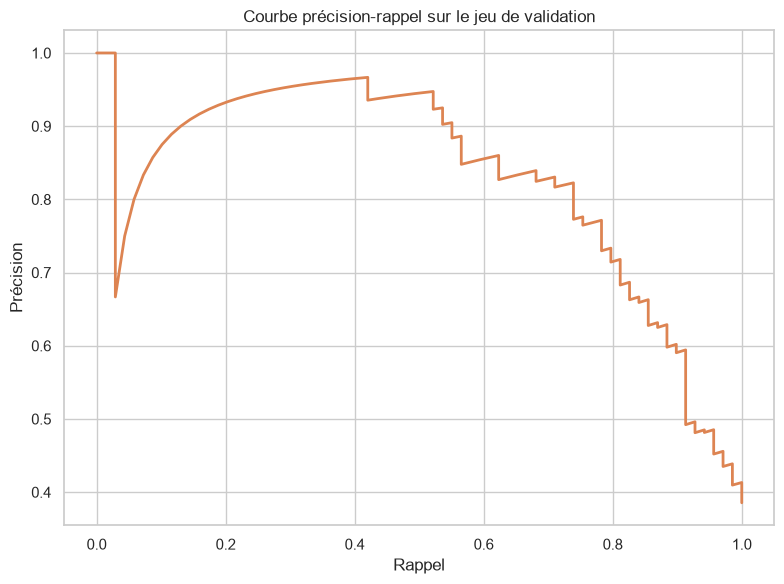

In [48]:
precision_values, recall_values, thresholds = (
    precision_recall_curve(
        y_validation,
        validation_probabilities
    )
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_values,
    precision_values,
    color="#DD8452",
    linewidth=2
)

plt.xlabel("Rappel")
plt.ylabel("Précision")
plt.title("Courbe précision-rappel sur le jeu de validation")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "validation_precision_recall_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Pour la soumission Kaggle, on conservera le seuil de `0.5`.

---

## Analyse des erreurs

Une analyse des erreurs permet d'identifier les profils de passagers les plus
difficiles à classifier.

Les faux positifs sont les passagers prédits survivants qui n'ont pas survécu. Les
faux négatifs sont les passagers prédits non-survivants qui ont réellement survécu.


In [49]:
error_analysis = X_validation.copy()

error_analysis["Actual"] = y_validation
error_analysis["Predicted"] = validation_predictions
error_analysis["SurvivalProbability"] = (
    validation_probabilities
)

error_analysis["ErrorType"] = np.select(
    condlist=[
        (
            (error_analysis["Actual"] == 0)
            & (error_analysis["Predicted"] == 1)
        ),
        (
            (error_analysis["Actual"] == 1)
            & (error_analysis["Predicted"] == 0)
        )
    ],
    choicelist=[
        "False positive",
        "False negative"
    ],
    default="Correct"
)

error_analysis["ErrorType"].value_counts()

ErrorType
Correct           147
False negative     16
False positive     16
Name: count, dtype: int64

### Faux positifs

In [50]:
false_positives = (
    error_analysis[
        error_analysis["ErrorType"]
        == "False positive"
    ]
    .sort_values(
        "SurvivalProbability",
        ascending=False
    )
)

false_positives[
    [
        "PassengerId",
        "Name",
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "SibSp",
        "Parch",
        "Cabin",
        "SurvivalProbability"
    ]
].head(15)

,PassengerId,Name,Sex,Age,Pclass,Fare,SibSp,Parch,Cabin,SurvivalProbability
297,298,"Allison, Miss. Helen Loraine",female,2.0,1,151.5500,1,2,C22 C26,0.975921
199,200,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,24.0,2,13.0000,0,0,NaN,0.815477
501,502,"Canavan, Miss. Mary",female,21.0,3,7.7500,0,0,NaN,0.755935
502,503,"O'Sullivan, Miss. Bridget Mary",female,NaN,3,7.6292,0,0,NaN,0.750869
578,579,"Caram, Mrs. Joseph (Maria Elias)",female,NaN,3,14.4583,1,0,NaN,0.727838
564,565,"Meanwell, Miss. (Marion Ogden)",female,NaN,3,8.0500,0,0,NaN,0.716414
799,800,"Van Impe, Mrs. Jean Baptiste (Rosalie Paula Go...",female,30.0,3,24.1500,1,1,NaN,0.708431
245,246,"Minahan, Dr. William Edward",male,44.0,1,90.0000,2,0,C78,0.675674
659,660,"Newell, Mr. Arthur Webster",male,58.0,1,113.2750,0,2,D48,0.664109
593,594,"Bourke, Miss. Mary",female,NaN,3,7.7500,0,2,NaN,0.651884


### Faux négatifs

In [51]:
false_negatives = (
    error_analysis[
        error_analysis["ErrorType"]
        == "False negative"
    ]
    .sort_values(
        "SurvivalProbability",
        ascending=True
    )
)

false_negatives[
    [
        "PassengerId",
        "Name",
        "Sex",
        "Age",
        "Pclass",
        "Fare",
        "SibSp",
        "Parch",
        "Cabin",
        "SurvivalProbability"
    ]
].head(15)

,PassengerId,Name,Sex,Age,Pclass,Fare,SibSp,Parch,Cabin,SurvivalProbability
271,272,"Tornquist, Mr. William Henry",male,25.0,3,0.0000,0,0,NaN,0.051295
804,805,"Hedman, Mr. Oskar Arvid",male,27.0,3,6.9750,0,0,NaN,0.064698
444,445,"Johannesen-Bratthammer, Mr. Bernt",male,NaN,3,8.1125,0,0,NaN,0.073474
570,571,"Harris, Mr. George",male,62.0,2,10.5000,0,0,NaN,0.087484
146,147,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,3,7.7958,0,0,NaN,0.090845
455,456,"Jalsevac, Mr. Ivan",male,29.0,3,7.8958,0,0,NaN,0.100051
553,554,"Leeni, Mr. Fahim (""Philip Zenni"")",male,22.0,3,7.2250,0,0,NaN,0.149309
17,18,"Williams, Mr. Charles Eugene",male,NaN,2,13.0000,0,0,NaN,0.162094
712,713,"Taylor, Mr. Elmer Zebley",male,48.0,1,52.0000,1,0,C126,0.188129
447,448,"Seward, Mr. Frederic Kimber",male,34.0,1,26.5500,0,0,NaN,0.203047


---

## Performances selon le sexe et la classe
Un score global peut cacher des différences importantes entre les groupes.

### Fonction d'évaluation par groupe

In [52]:
def accuracy_by_group(
    dataframe,
    group_column
):
    return (
        dataframe
        .groupby(group_column)
        .apply(
            lambda group: pd.Series({
                "count": len(group),
                "accuracy": accuracy_score(
                    group["Actual"],
                    group["Predicted"]
                ),
                "actual_survival_rate": (
                    group["Actual"].mean()
                ),
                "predicted_survival_rate": (
                    group["Predicted"].mean()
                )
            }),
            include_groups=False
        )
        .round(3)
    )

### Selon le sexe

In [53]:
accuracy_by_group(
    error_analysis,
    "Sex"
)

,count,accuracy,actual_survival_rate,predicted_survival_rate
Sex,,,,
female,61.0,0.820,0.738,0.918
male,118.0,0.822,0.203,0.110


### Selon la classe

In [54]:
accuracy_by_group(
    error_analysis,
    "Pclass"
)

,count,accuracy,actual_survival_rate,predicted_survival_rate
Pclass,,,,
1,45.0,0.689,0.556,0.511
2,34.0,0.912,0.588,0.559
3,100.0,0.850,0.240,0.270


### Selon le sexe et la classe

In [55]:
group_performance = (
    error_analysis
    .groupby(["Sex", "Pclass"])
    .apply(
        lambda group: pd.Series({
            "count": len(group),
            "accuracy": accuracy_score(
                group["Actual"],
                group["Predicted"]
            ),
            "actual_survival_rate": (
                group["Actual"].mean()
            ),
            "predicted_survival_rate": (
                group["Predicted"].mean()
            )
        }),
        include_groups=False
    )
    .round(3)
)

group_performance

count  accuracy  actual_survival_rate  predicted_survival_rate
Sex    Pclass                                                                
female 1        15.0     0.933                 0.933                    1.000
       2        18.0     0.944                 0.944                    1.000
       3        28.0     0.679                 0.500                    0.821
male   1        30.0     0.567                 0.367                    0.267
       2        16.0     0.875                 0.188                    0.062
       3        72.0     0.917                 0.139                    0.056

Les performances par sous-groupe doivent être interprétées avec prudence, car le jeu
de validation contient peu d'observations et certains groupes sont très petits.

Cette analyse ne constitue pas une mesure complète d'équité algorithmique. Elle permet
néanmoins de vérifier si l'accuracy globale masque des écarts importants entre les
groupes.

---

## Importance par permutation

On rappel que l'importance par permutation mesure la baisse de performance lorsqu'une variable brute est mélangée aléatoirement.

Elle présente deux avantages :
- elle est compatible avec tous les modèles
- elle évalue le pipline complet, y compris les variables créées à partir des colonnes brutes.

Par exemple :
- permuter `Name` pertube `Title` et `NameLength`
- permuter `Cabin` pertube `Deck` et `CabinKnown`
- permuter `SibSp` pertube également `FamilySize` et `FamilyGroup`

In [56]:
permutation_results = permutation_importance(
    estimator=best_pipeline,
    X=X_validation,
    y=y_validation,
    scoring="accuracy",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

raw_feature_importance = pd.DataFrame({
    "feature": X_validation.columns,
    "importance_mean": (
        permutation_results.importances_mean
    ),
    "importance_std": (
        permutation_results.importances_std
    )
}).sort_values(
    "importance_mean",
    ascending=False
)

raw_feature_importance

,feature,importance_mean,importance_std
2,Name,0.100372,0.026143
3,Sex,0.071881,0.020989
5,SibSp,0.040037,0.009577
4,Age,0.024953,0.011695
8,Fare,0.021601,0.007317
1,Pclass,0.009870,0.008119
6,Parch,0.007449,0.008574
0,PassengerId,0.000000,0.000000
7,Ticket,-0.000372,0.008151
10,Embarked,-0.001117,0.008703


### Visualisation

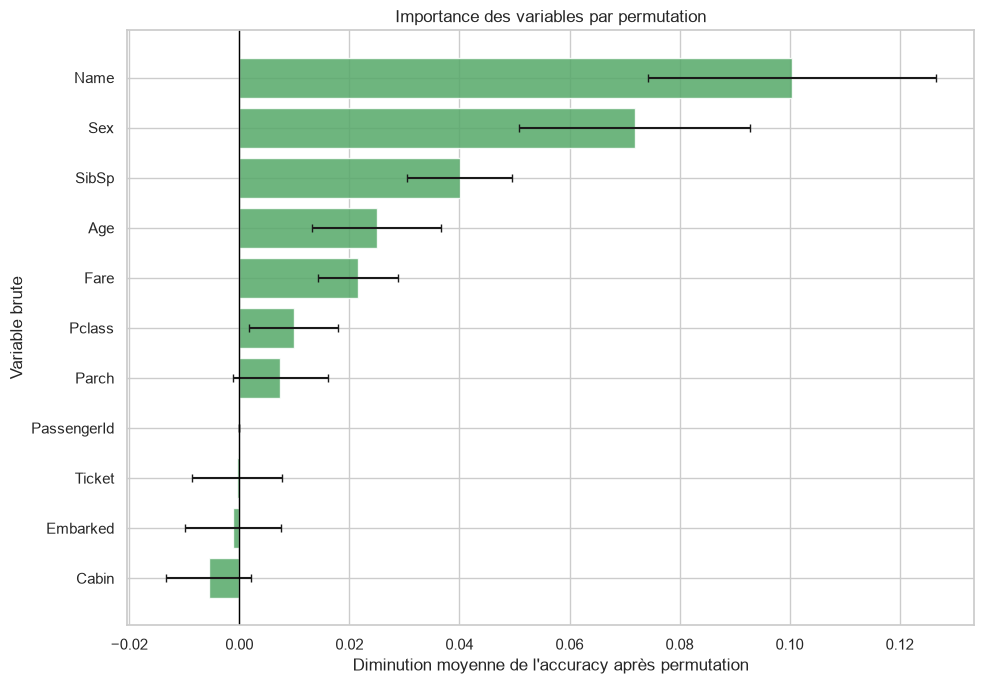

In [57]:
plot_importance = (
    raw_feature_importance
    .sort_values(
        "importance_mean",
        ascending=True
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
    color="#55A868",
    alpha=0.85,
    capsize=3
)

plt.axvline(
    x=0,
    color="black",
    linewidth=1
)

plt.xlabel(
    "Diminution moyenne de l'accuracy après permutation"
)
plt.ylabel("Variable brute")
plt.title("Importance des variables par permutation")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "permutation_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

L'importance par permutation décrit l'utilité prédictive des variables pour ce modèle
et sur ce jeu de validation. Elle ne représente pas une relation causale.

Une importance négative ou proche de zéro peut apparaître lorsqu'une variable est peu
utile, redondante avec d'autres variables ou lorsque les résultats varient en raison
de la petite taille du jeu de validation.

---

## Sauvegarde des résultats de validation

In [58]:
metrics_path = (
    REPORTS_DIR
    / "validation_metrics.json"
)

serializable_metrics = {
    metric: float(value)
    for metric, value in validation_metrics.items()
}

with open(
    metrics_path,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        serializable_metrics,
        file,
        indent=4,
        ensure_ascii=False
    )

classification_report_df.to_csv(
    REPORTS_DIR / "classification_report.csv"
)

raw_feature_importance.to_csv(
    REPORTS_DIR / "permutation_importance.csv",
    index=False
)

error_analysis.to_csv(
    REPORTS_DIR / "validation_error_analysis.csv",
    index=False
)

print("Résultats d'évaluation sauvegardés.")

Résultats d'évaluation sauvegardés.


---

# Entraînement final et soumission

Une fois le protocole d'évaluation terminé, le meilleur pipeline est réentraîné sur
l'ensemble des données étiquetées. Cette étape permet d'exploiter toutes les
observations disponibles avant de générer les prédictions du jeu de test Kaggle.

In [60]:
final_pipeline = clone(
    best_pipeline
)

final_pipeline.fit(
    X,
    y
)

print(
    "Pipeline final entraîné sur "
    f"{len(X)} observations."
)

Pipeline final entraîné sur 891 observations.


---

## Génération des prédictions Kaggle

In [61]:
test_predictions = final_pipeline.predict(
    X_test
)

test_probabilities = final_pipeline.predict_proba(
    X_test
)[:, 1]

Contrôles

In [62]:
print(
    "Distribution des prédictions :"
)

print(
    pd.Series(test_predictions)
    .value_counts()
    .sort_index()
)

print(
    "\nTaux de survie prédit :",
    round(test_predictions.mean(), 4)
)

Distribution des prédictions :
0    250
1    168
Name: count, dtype: int64

Taux de survie prédit : 0.4019


Vérifications

In [63]:
assert len(test_predictions) == len(test_df)
assert set(np.unique(test_predictions)).issubset({0, 1})
assert not np.isnan(test_predictions).any()

print("Prédictions valides.")

Prédictions valides.


---

## Création de `submission.csv`

Le fichier doit contenir exactement `PassengerId,Survived`

In [64]:
submission = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "Survived": test_predictions.astype(int)
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


### Vérifications

In [65]:
assert submission.shape == (418, 2)

assert submission.columns.tolist() == [
    "PassengerId",
    "Survived"
]

assert submission["PassengerId"].is_unique
assert submission["Survived"].isin([0, 1]).all()
assert submission.isna().sum().sum() == 0

print("Format de la soumission validé.")

Format de la soumission validé.


### Sauvegarde

In [66]:
submission_path = (
    SUBMISSIONS_DIR
    / "submission.csv"
)

submission.to_csv(
    submission_path,
    index=False
)

print(
    f"Soumission enregistrée dans : {submission_path}"
)

Soumission enregistrée dans : c:\Users\hoare\Programming\project\titanic-project\submissions\submission.csv


On affiche les premières lignes pour vérifications

In [67]:
pd.read_csv(submission_path).head(10)

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1
5,897,0
6,898,1
7,899,0
8,900,1
9,901,0


---

## Comparaison avec le fichier d'exemple

In [68]:
gender_submission_path = (
    DATA_DIR
    / "gender_submission.csv"
)

if gender_submission_path.exists():
    sample_submission = pd.read_csv(
        gender_submission_path
    )

    print(
        "Exemple officiel :",
        sample_submission.shape
    )

    print(
        "Notre soumission :",
        submission.shape
    )

    assert submission.columns.tolist() == (
        sample_submission.columns.tolist()
    )

    assert submission["PassengerId"].equals(
        sample_submission["PassengerId"]
    )

    print(
        "Notre soumission respecte "
        "le format de l'exemple officiel."
    )
else:
    print(
        "gender_submission.csv n'a pas été trouvé. "
        "Les autres contrôles restent valides."
    )

Exemple officiel : (418, 2)
Notre soumission : (418, 2)
Notre soumission respecte le format de l'exemple officiel.


---

## Enregistrement des probabilités

In [69]:
test_probability_output = pd.DataFrame({
    "PassengerId": test_passenger_ids,
    "SurvivalProbability": test_probabilities,
    "PredictedSurvival": test_predictions.astype(int)
})

test_probability_output.to_csv(
    SUBMISSIONS_DIR / "test_probabilities.csv",
    index=False
)

test_probability_output.head()

,PassengerId,SurvivalProbability,PredictedSurvival
0,892,0.078530,0
1,893,0.461784,0
2,894,0.125219,0
3,895,0.057608,0
4,896,0.704142,1


---

## Sauvegarde de la pipeline final

In [70]:
model_path = (
    MODELS_DIR
    / "titanic_pipeline.joblib"
)

joblib.dump(
    final_pipeline,
    model_path
)

print(
    f"Pipeline sauvegardé dans : {model_path}"
)

Pipeline sauvegardé dans : c:\Users\hoare\Programming\project\titanic-project\models\titanic_pipeline.joblib


Ce fichier contient :
- le feature engineering
- l'imputation
- la standardisation
- l'encodage;
- le modèle final

---

## Test du rechargement du modèle

In [71]:
loaded_pipeline = joblib.load(
    model_path
)

reloaded_predictions = loaded_pipeline.predict(
    X_test
)

assert np.array_equal(
    test_predictions,
    reloaded_predictions
)

print(
    "Le pipeline sauvegardé a été rechargé "
    "avec succès."
)

Le pipeline sauvegardé a été rechargé avec succès.


Test du prédiction individuelle

In [72]:
single_passenger = X_test.iloc[[0]]

single_prediction = loaded_pipeline.predict(
    single_passenger
)[0]

single_probability = loaded_pipeline.predict_proba(
    single_passenger
)[0, 1]

print(
    "Prédiction :",
    int(single_prediction)
)

print(
    "Probabilité de survie :",
    round(float(single_probability), 3)
)

Prédiction : 0
Probabilité de survie : 0.079


---

## Inspection des variables transformées

In [73]:
final_preprocessor = final_pipeline.named_steps[
    "preprocessing"
]

transformed_feature_names = (
    final_preprocessor
    .get_feature_names_out()
)

print(
    "Nombre de variables après preprocessing :",
    len(transformed_feature_names)
)

transformed_feature_names[:30]

Nombre de variables après preprocessing : 56


array(['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'NameLength',
       'Pclass_1', 'Pclass_2', 'Pclass_3', 'Sex_female', 'Sex_male',
       'Embarked_C', 'Embarked_Q', 'Embarked_S', 'IsAlone_0', 'IsAlone_1',
       'FamilyGroup_Alone', 'FamilyGroup_Large', 'FamilyGroup_Medium',
       'FamilyGroup_Small', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'CabinKnown_0', 'CabinKnown_1',
       'Deck_A', 'Deck_B', 'Deck_C'], dtype=object)

sous forme de tableau, on a

In [74]:
transformed_features_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names
})

transformed_features_df.head(30)

,transformed_feature
0,Age
1,SibSp
2,Parch
3,Fare
4,FamilySize
5,NameLength
6,Pclass_1
7,Pclass_2
8,Pclass_3
9,Sex_female


---

## Conclusion

Un pipeline complet de classification a été construit afin de prédire la survie des
passagers du Titanic.

### Méthodologie

Le protocole a été organisé en plusieurs étapes :

1. séparation d'un jeu de validation final stratifié ;
2. comparaison des modèles uniquement sur le jeu de développement ;
3. validation croisée stratifiée à cinq plis ;
4. optimisation des hyperparamètres du meilleur candidat ;
5. évaluation unique sur le jeu de validation ;
6. analyse des erreurs et importance par permutation ;
7. réentraînement sur l'ensemble des données ;
8. génération de la soumission Kaggle.

### Pipeline

Le pipeline final regroupe :

- la création de variables ;
- l'imputation des variables numériques par la médiane ;
- l'imputation des catégories par la modalité la plus fréquente ;
- la standardisation des variables numériques ;
- le one-hot encoding des variables catégorielles ;
- le modèle de classification.

Cette organisation garantit que les transformations statistiques sont ajustées
uniquement sur les données d'entraînement de chaque étape, ce qui limite les risques
de fuite de données.

### Variables créées

Le feature engineering a notamment introduit :

- `FamilySize` ;
- `IsAlone` ;
- `FamilyGroup` ;
- `Title` ;
- `CabinKnown` ;
- `Deck` ;
- `TicketPrefix` ;
- `NameLength`.

### Évaluation

Le modèle final dépasse la baseline qui prédit systématiquement la classe majoritaire.
Les performances ont été étudiées avec plusieurs métriques :

- accuracy ;
- précision ;
- rappel ;
- F1-score ;
- ROC-AUC ;
- matrice de confusion.

L'analyse des erreurs montre que certains profils restent difficiles à classifier.
Les performances par sexe et par classe doivent être interprétées avec prudence en
raison de la petite taille du jeu de données.

### Limites

- Le dataset contient seulement 891 observations étiquetées.
- Les résultats peuvent varier selon le découpage des données.
- Certaines variables créées sont redondantes.
- L'importance prédictive d'une variable ne représente pas une relation causale.
- Certains passagers appartiennent aux mêmes familles ou partagent le même billet, ce
  qui peut créer des dépendances entre les observations.
- Le score Kaggle dépend d'un jeu de test dont les réponses ne sont pas publiques.

### Livrables

Le projet génère :

- un pipeline entraîné dans `models/titanic_pipeline.joblib` ;
- une soumission dans `submissions/submission.csv` ;
- les résultats des modèles dans `reports/model_comparison.csv` ;
- les métriques finales dans `reports/validation_metrics.json` ;
- les figures d'évaluation dans `reports/figures/`.

Le projet est maintenant reproductible depuis les données brutes jusqu'aux
prédictions finales.
